In [1]:
import gpflow as gpf
from atkernel import TransferKernel
import tensorflow as tf
import numpy as np
import sys
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple
from at_covariances import Kuu_conditional, Kuf_conditional, TransferInducingPoints

def woodbury(A, U, C, V, invert_A=False):
    if invert_A:
        return tf.linalg.inv(A)
    return tf.matmul()

class SparseCMOGP(gpf.models.GPModel, InternalDataTrainingLossMixin):
    def __init__(self, data, kernel, likelihood, mean_function=None, num_latent_gps=2, inducing_variable=[]):
        super().__init__(kernel, likelihood, mean_function, num_latent_gps)
        self.data = data   
        self.kernel = kernel
        self.likelihood = likelihood
        self.inducing_variable = InducingPoints(inducing_variable)
        self.mean_function = gpf.mean_functions.Zero()
        self.conditioning_indices = [0]

        
    def conditional_likelihood(self, *args, **kwargs) -> tf.Tensor:

        # Rebuild: look at all unique indices. 
        # Then, figure out what set to condition on
        # Then, gather all conditioning variables as source, rest as target.
        def get_condition_number(M, name=""):
            s = tf.linalg.svd(M, compute_uv=False)
            tf.print(f"condition number {name}", s[0]/s[-1], s[0], s[-1])
            return 

        Xs, Ys = self.data
        Kall = self.kernel(Xs)
        Xind = self.inducing_variable.Z
        #tf.print(Kall.shape)

        # Determine what is source and what is target (currently use only one target var)
        As = (Ys[:,1]  == 0)
        Bs = (Ys[:,1]  == 1)

        Ax, Ay = tf.reshape(Xs[:,0][As], (-1, 1)), tf.reshape(Ys[:,0][As], (-1, 1))
        Bx, By = tf.reshape(Xs[:,0][Bs], (-1, 1)), tf.reshape(Ys[:,0][Bs], (-1, 1))

        indices_A = tf.reshape(tf.where(As), [-1])
        indices_B = tf.reshape(tf.where(Bs), [-1])

        # Exact matrices
        Kbb = tf.gather(tf.gather(Kall, indices_B, axis=0), indices_B, axis=1) + tf.linalg.diag(tf.squeeze(self.likelihood.target.variance_at(Bx)))
        Kaa = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_A, axis=1) + tf.linalg.diag(tf.squeeze(self.likelihood.source.variance_at(Ax)))
        Kab = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_B, axis=1)
        Kba = tf.transpose(Kab)

        # Approximate matrices
        Kma = self.kernel(self.inducing_variable.Z, Xs[As])
        Kmb = self.kernel(self.inducing_variable.Z, Xs[Bs])
        Kam = tf.transpose(Kma)
        Kmm = self.kernel(self.inducing_variable.Z) + np.eye(len(Xind), dtype=np.float64) * 1e-4
        L_Kmm = tf.linalg.cholesky(Kmm)
        Lmm_inv_kma = tf.linalg.triangular_solve(L_Kmm, Kma)
        Lmm_inv_kmb = tf.linalg.triangular_solve(L_Kmm, Kmb)

        # Full approximations of the exact matrices
        Qaa = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kma)
        Qab = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kmb)
        Qba = tf.transpose(Qab)
        
        LQaa = tf.linalg.cholesky(Qaa + tf.eye(len(Qaa), dtype=tf.float64) * 1e-5)
        LQaa_Kab = tf.linalg.triangular_solve(LQaa, Qab)
        Qbb_approx = tf.matmul(LQaa_Kab, LQaa_Kab, transpose_a=True)
        Qbb = tf.matmul(tf.transpose(Lmm_inv_kmb), Lmm_inv_kmb)

        # FITC-type diagonal
        Lambda = tf.linalg.diag(tf.linalg.diag_part(Kaa - Qaa))

        # Compute conditional mu
        Qaa_L = tf.linalg.cholesky(Qaa + Lambda) 
        gamma = tf.linalg.triangular_solve(tf.transpose(Qaa_L), tf.linalg.triangular_solve(Qaa_L, Ay, lower=False))
        mu_t = tf.matmul(Qba, gamma)
        
        # Compute conditional variance
        Lambda_target =  tf.linalg.diag(tf.linalg.diag_part(Kbb - Qbb_approx))
        C_t = Qbb - Qbb_approx + Lambda_target 

        delta = By - mu_t
        L_t = tf.linalg.cholesky(C_t)
        alpha_t = tf.linalg.triangular_solve(L_t, delta, lower=True)
        n_source = tf.cast(tf.shape(Bx)[0], Bx.dtype)
        logdet_t = 2 * tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L_t)))
        lml = -0.5 * (logdet_t + tf.reduce_sum(alpha_t ** 2) + n_source * tf.cast(tf.math.log(2*np.pi), Ax.dtype))
        return tf.squeeze(lml)

    def maximum_log_likelihood_objective(self):
        return self.conditional_likelihood()


    def predict_f(
        self, Xnew, full_cov: bool = False, full_output_cov: bool = False):
        r"""
        Allegedly, the GP prediction stays the same, so instead of creating an inference shaped footgun, use GPFlow methods.
        This method computes predictions at X \in R^{N \x D} input points

        .. math::
            p(F* | Y)

        where F* are points on the GP at new data points, Y are noisy observations at training data
        points.
        """

        Xs, Ys = self.data
        Xind = self.inducing_variable.Z
        Kall = self.kernel(Xs)
        err = (Ys - self.mean_function(Xs))[:,0][:,None]
      
        As = (Ys[:,1] == 0)
        Bs = (Ys[:,1] == 1)

        knn = self.kernel(Xnew, full_cov=full_cov) + tf.squeeze(self.likelihood.target.variance_at(Xnew))

        Ax, Ay = tf.reshape(Xs[:,0][As], (-1, 1)), tf.reshape(Ys[:,0][As], (-1, 1))
        Bx, By = tf.reshape(Xs[:,0][Bs], (-1, 1)), tf.reshape(Ys[:,0][Bs], (-1, 1))

        indices_A = tf.reshape(tf.where(As), [-1])
        indices_B = tf.reshape(tf.where(Bs), [-1])
       
        # Compute exact kernel parts
        Kbb = tf.gather(tf.gather(Kall, indices_B, axis=0), indices_B, axis=1) 
        Kaa = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_A, axis=1) 
        Kab = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_B, axis=1)
        Kba = tf.transpose(Kab)

        # Compute inducing points x rest data 
        Kma = self.kernel(self.inducing_variable.Z, Xs[As])
        Kmb = self.kernel(self.inducing_variable.Z, Xs[Bs])
        Kam = tf.transpose(Kma)
        Kmm = self.kernel(self.inducing_variable.Z) + np.eye(len(Xind.numpy()), dtype=np.float64) * 1e-4
        L_Kmm = tf.linalg.cholesky(Kmm)
        Lmm_inv_kma = tf.linalg.triangular_solve(L_Kmm, Kma)
        Lmm_inv_kmb = tf.linalg.triangular_solve(L_Kmm, Kmb)

        # Use above to compute approximations and diagonal
        Qaa = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kma)
        Qab = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kmb)
        Qba = tf.transpose(Qab)
        Qbb = tf.matmul(tf.transpose(Lmm_inv_kmb), Lmm_inv_kmb)
        Lambda = tf.linalg.diag(tf.linalg.diag_part(Kaa - Qaa))
        Lambda_t = tf.linalg.diag(tf.linalg.diag_part(Kbb - Qbb))

        #tf.print(self.inducing_variable.Z)
        K_fitc = tf.concat((tf.concat((Qaa + Lambda, Qab), 1), tf.concat((Qba, Qbb + Lambda_t), 1)), 0)
        L_Kfitc = tf.linalg.cholesky(K_fitc + tf.eye(len(Xs), dtype=tf.float64) * 0.0001)

        #tf.print(kmm_plus_s.shape)
        # Construct Kmn
        Knm = self.kernel(Xs, self.inducing_variable.Z) @ tf.linalg.inv(Kmm) @ self.kernel(self.inducing_variable.Z, Xnew)
        LfitcKnm = tf.linalg.triangular_solve(L_Kfitc, Knm)
        Lfitcy = tf.linalg.triangular_solve(L_Kfitc, err, lower=True)
      
        cond = tf.transpose(LfitcKnm) @ LfitcKnm  
        f_mean_zero = tf.transpose(LfitcKnm) @ Lfitcy
        f_var = tf.expand_dims(tf.linalg.diag_part(knn - cond), 1)
        fvar = knn - tf.reduce_sum(tf.square(LfitcKnm), -2)  # [..., N]
        fvar = tf.expand_dims(fvar, -2)
        #tf.print("fm0", f_mean_zero.shape)
        f_mean = f_mean_zero + self.mean_function(Xnew[:,0][:,None])
        return f_mean, f_var

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()


2026-04-10 16:27:28.316113: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 16:27:28.318006: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 16:27:28.345057: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 16:27:28.346190: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-10 16:27:28.975746: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

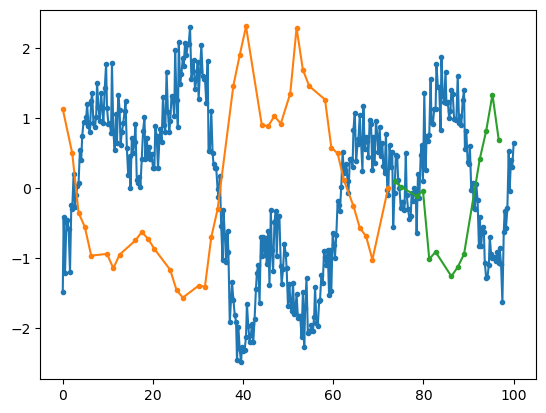

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value       │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────┤
│ SparseCMOGP.kernel

In [ ]:
Xall = np.linspace(0, 100, 1000).reshape(-1, 1)
k = gpf.kernels.RBF(lengthscales=5, variance=1) #+ gpf.kernels.Linear(0.01)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall[:,0]), k(Xall))
ind_1 = np.linspace(0, 999, 365, dtype=int)
ind_2 = np.array([i for i in ind_1[0:] if i % 7 == 0])
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2 - X2[0]
y2 = -y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = -ytest.reshape(-1, 1) + np.random.normal(0, 0.2, len(ytest)).reshape(-1, 1) 

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.3, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.2, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
ivs = np.linspace(0, 100, 50).reshape(-1, 1)
ivs = np.hstack((ivs, np.ones_like(ivs)))
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
m = SparseCMOGP((X, y), kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

In [ ]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)
 

TensorShape([404, 404])
TensorShape([404, 404])


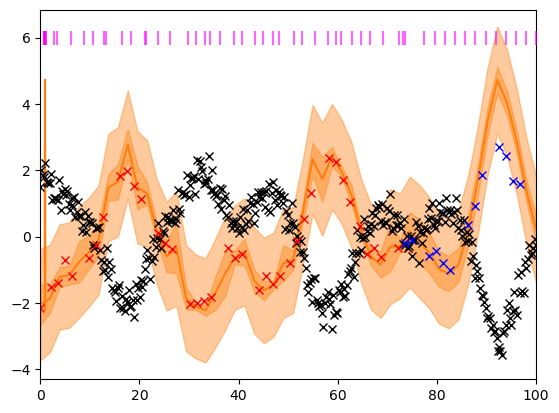

1.7530167705082396

In [ ]:
from sklearn.metrics import mean_squared_error
Xnew = np.linspace(0, 100, len(ind_2)).reshape(-1, 1)
Xnew = np.hstack((Xnew, np.ones_like(Xnew)))
fmean, fvar = m.predict_f(Xnew)
ymean, yvar = m.predict_y(Xnew)
plt.plot(Xnew, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xnew[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xnew[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z, np.ones_like(ivs)*6, marker="|", color="magenta", zorder=100, s=100, alpha=0.6)
plt.xlim([0, 100])
plt.show()

mean_squared_error(ytest, fmean[TEST_INDEX:].numpy().flatten())

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

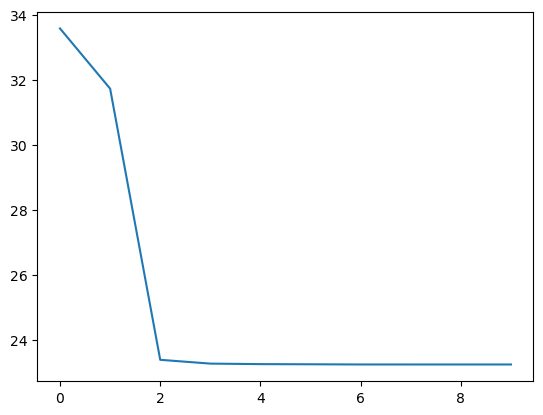

In [ ]:
kern = gpf.kernels.RBF()
m = gpf.models.GPR((X2, y2), kernel=kern)
gpf.utilities.print_summary(m)
optimize(m)

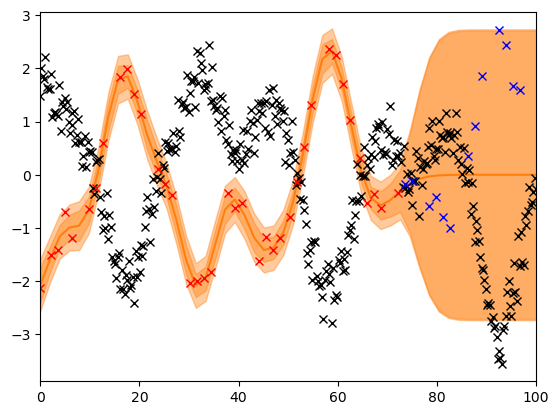

1.9400621813498868

In [ ]:
Xnew = np.linspace(0, 100, len(ind_2)).reshape(-1, 1)
fmean, fvar = m.predict_f(Xnew)
ymean, yvar = m.predict_y(Xnew)
plt.plot(Xnew, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xnew[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xnew[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.xlim([0, 100])
plt.show()


mean_squared_error(ytest, fmean[TEST_INDEX:].numpy().flatten())